In [1]:
# Import required libraries
import pandas as pd                                    # For loading and handling the CSV dataset
from sklearn.model_selection import train_test_split   # For splitting data into train/test sets
import torch                                           # Core PyTorch library
from torch.utils.data import Dataset, DataLoader       # For creating custom datasets and batching
import torch.nn as nn                                  # Neural network building blocks (layers, losses)
import torch.optim as optim                            # Optimizers (SGD, Adam, etc.)
import matplotlib.pyplot as plt                        # For visualizing sample images
import os                                              # For file path operations when saving/loading model

In [2]:
# Set random seed for reproducibility so weight initialization and shuffling are deterministic
torch.manual_seed(42)

In [3]:
# Detect available hardware: use GPU (CUDA) if present, otherwise fall back to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [5]:
# Load the Fashion-MNIST training data from CSV file
# Each row = 1 image (label + 784 pixel values flattened from a 28x28 grayscale image)
df = pd.read_csv(r'H:\01_Training\ContentSlides_AgenticAI\Code\Pytorch\fmnist_small.csv')
df.head()  # Preview the first 5 rows

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [6]:
df.fillna(0,inplace=True)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,1,0,0,0,0,0,0,0,0,0,...,69,12,0,0,0,0,0,0,0,0
5996,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5997,8,0,0,0,0,0,0,0,0,0,...,39,47,2,0,0,29,0,0,0,0
5998,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
# Inspect dataset dimensions: (number_of_samples, number_of_columns)
# Expected: (60000, 785) -> 60000 images, 1 label column + 784 pixel columns
df.shape

(6000, 785)

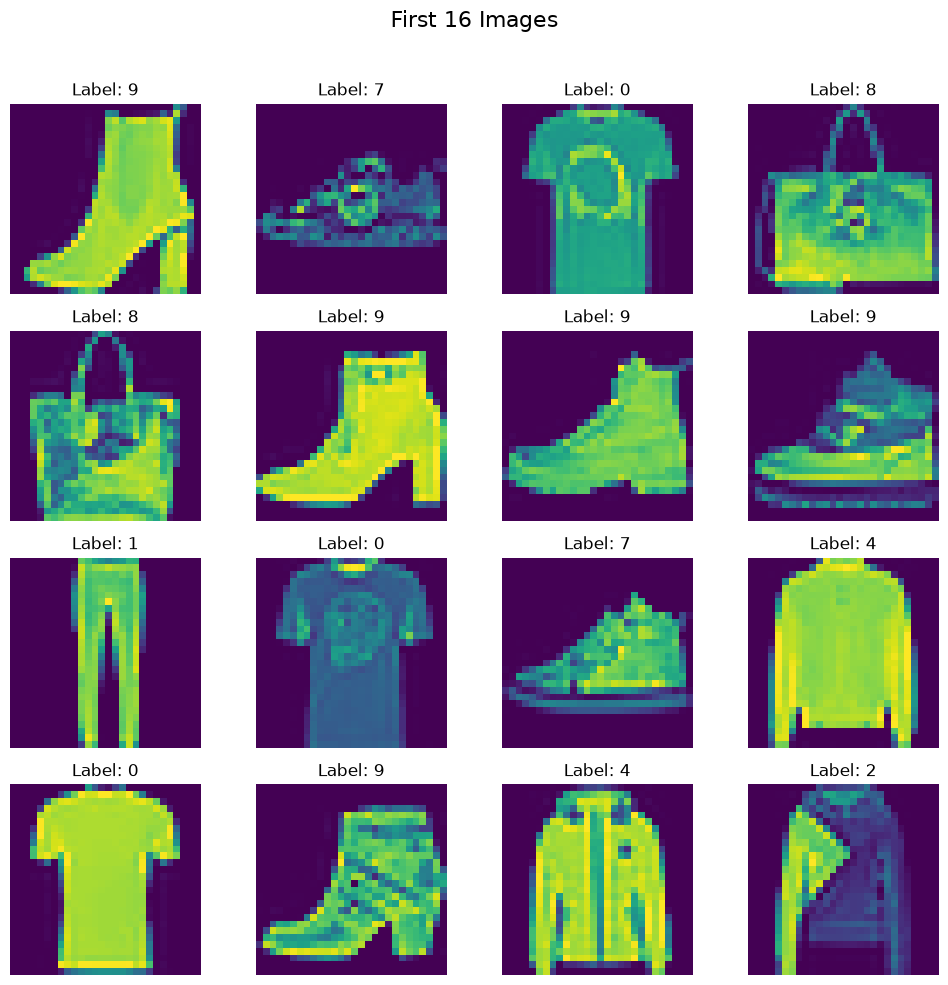

In [8]:
# Visualize the first 16 images in a 4x4 grid to sanity-check the data
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Loop through the first 16 rows of the dataframe and render each as a 28x28 image
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)   # Drop label column, reshape pixels to 28x28
    ax.imshow(img)                                # Display the image
    ax.axis('off')                                # Hide axis ticks for a cleaner display
    ax.set_title(f"Label: {df.iloc[i, 0]}")       # Show the corresponding class label

plt.tight_layout(rect=[0, 0, 1, 0.96])            # Reserve top area for the suptitle
plt.show()


In [9]:
# Separate features (X) and target labels (y)
# X = all pixel columns (columns 1 onwards), y = the label column (column 0)
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [10]:
# Split the data into 80% training and 20% testing
# random_state=42 ensures the split is reproducible across runs
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Normalize pixel values from [0, 255] to [0, 1]
# Scaling helps the neural network train faster and more stably
X_train = X_train/255.0
X_test = X_test/255.0

In [12]:
# Custom PyTorch Dataset class - wraps numpy arrays as a Dataset that DataLoader can iterate over
class CustomDataset(Dataset):

  def __init__(self, features, labels):
    # Convert numpy arrays to PyTorch tensors
    # Features as float32 (model input), labels as long/int64 (CrossEntropyLoss requirement)
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    # Returns total number of samples - required by DataLoader
    return len(self.features)

  def __getitem__(self, index):
    # Returns a single (feature, label) pair for the given index
    return self.features[index], self.labels[index]

In [13]:
# Wrap the training arrays in our custom Dataset
train_dataset = CustomDataset(X_train, y_train)

In [14]:
# Wrap the test arrays in our custom Dataset
test_dataset = CustomDataset(X_test, y_test)

In [15]:
# Create DataLoaders to feed mini-batches into the model
# batch_size=32  -> 32 samples per gradient update
# shuffle=True   -> reshuffle training data every epoch to reduce overfitting (off for test)
# pin_memory=True-> speeds up CPU->GPU memory transfer when training on CUDA
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [17]:
# Number of mini-batches per epoch ( train samples / batch_size 32 = 1500)
len(train_loader)

150

In [ ]:
# Define the neural network architecture: a simple fully-connected (ANN) classifier
# Architecture: 784 -> 128 -> 64 -> 10
class MyNN(nn.Module):

  def __init__(self, num_features):
    super().__init__()
    # nn.Sequential chains layers together; data flows top to bottom
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),   # Input layer  -> 128 hidden neurons
        nn.ReLU(),                      # Non-linear activation
        nn.Linear(128, 64),              # Hidden layer -> 64 hidden neurons
        nn.ReLU(),                      # Non-linear activation
        nn.Linear(64, 10)
    )

  def forward(self, x):
    # Defines how the input flows through the network during a forward pass
    return self.model(x)


In [19]:
# Hyperparameters for the training run
learning_rate = 0.1   # Step size for the optimizer (larger = faster but less stable)
epochs = 100          # Number of complete passes over the training dataset

In [20]:
# Instantiate the model and move it to the chosen device (GPU/CPU)
model = MyNN(X_train.shape[1])    # X_train.shape[1] = 784 input features
model = model.to(device)

# Loss function: CrossEntropyLoss combines softmax + negative log-likelihood for multi-class classification
criterion = nn.CrossEntropyLoss()

# Optimizer: Stochastic Gradient Descent updates the model weights using the computed gradients
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [21]:
# ----- Training loop -----
# Iterates over the dataset for `epochs` passes, updating weights each mini-batch.
# We also record the average loss per epoch for BOTH train and test sets, so the
# learning curves can be plotted afterwards (see the plotting cell at the end).

train_losses = []   # Average TRAINING loss after each epoch
test_losses = []    # Average TEST loss after each epoch

for epoch in range(epochs):

  # ---------- Training phase ----------
  model.train()          # Training mode (enables Dropout / BatchNorm updates if present)
  total_epoch_loss = 0   # Accumulator for the epoch's total loss

  for batch_features, batch_labels in train_loader:

    # Move the current mini-batch to GPU/CPU
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # Forward pass: compute model predictions for this batch
    outputs = model(batch_features)

    # Compute the loss between predictions and true labels
    loss = criterion(outputs, batch_labels)

    # Backward pass:
    optimizer.zero_grad()   # Reset gradients from the previous step (otherwise they accumulate)
    loss.backward()         # Compute gradients of the loss w.r.t. all model parameters

    # Update model weights using the optimizer
    optimizer.step()

    # Keep a running sum of the batch losses to compute the epoch average
    total_epoch_loss = total_epoch_loss + loss.item()

    # print(loss.item())   # Per-batch loss (very verbose: 59 lines x 100 epochs)

  # Average TRAIN loss for this epoch = total loss / number of batches
  avg_train_loss = total_epoch_loss/len(train_loader)
  train_losses.append(avg_train_loss)

  # ---------- Evaluation phase (test loss for the SAME epoch) ----------
  # No weight updates here - we only measure how well the model generalizes.
  model.eval()             # Evaluation mode
  total_test_loss = 0

  with torch.no_grad():    # Disable gradient tracking -> faster and uses less memory
    for batch_features, batch_labels in test_loader:
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
      outputs = model(batch_features)
      total_test_loss = total_test_loss + criterion(outputs, batch_labels).item()

  # Average TEST loss for this epoch
  avg_test_loss = total_test_loss/len(test_loader)
  test_losses.append(avg_test_loss)

  print(f'Epoch: {epoch + 1} , Train Loss: {avg_train_loss:.4f} , Test Loss: {avg_test_loss:.4f}')


h:\01_Training\ContentSlides_AgenticAI\Code\all_envs\pt_env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
h:\01_Training\ContentSlides_AgenticAI\Code\all_envs\pt_env\Lib\site-packages\torch\nn\modules\module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Epoch: 1 , Train Loss: 2.2943 , Test Loss: 2.2796
Epoch: 2 , Train Loss: 2.1942 , Test Loss: 2.1043
Epoch: 3 , Train Loss: 1.9887 , Test Loss: 1.8907
Epoch: 4 , Train Loss: 1.8717 , Test Loss: 1.8475
Epoch: 5 , Train Loss: 1.8339 , Test Loss: 1.8033
Epoch: 6 , Train Loss: 1.8005 , Test Loss: 1.7933
Epoch: 7 , Train Loss: 1.7733 , Test Loss: 1.7557
Epoch: 8 , Train Loss: 1.7549 , Test Loss: 1.7534
Epoch: 9 , Train Loss: 1.7407 , Test Loss: 1.7742
Epoch: 10 , Train Loss: 1.7325 , Test Loss: 1.7471
Epoch: 11 , Train Loss: 1.7247 , Test Loss: 1.7512
Epoch: 12 , Train Loss: 1.7239 , Test Loss: 1.7350
Epoch: 13 , Train Loss: 1.7184 , Test Loss: 1.7361
Epoch: 14 , Train Loss: 1.7129 , Test Loss: 1.7193
Epoch: 15 , Train Loss: 1.7077 , Test Loss: 1.7241
Epoch: 16 , Train Loss: 1.7089 , Test Loss: 1.7343
Epoch: 17 , Train Loss: 1.7007 , Test Loss: 1.7229
Epoch: 18 , Train Loss: 1.6994 , Test Loss: 1.7242
Epoch: 19 , Train Loss: 1.6961 , Test Loss: 1.7161
Epoch: 20 , Train Loss: 1.6907 , Test Lo

In [22]:
# ===========================================================
# SAVE THE TRAINED MODEL
# ===========================================================
# After training is complete, we persist the model to disk so it can be
# reused later for inference without having to retrain from scratch
# (training is expensive in time and compute).
#
# PyTorch has two common ways to save a model:
#   1) Save ONLY the state_dict (RECOMMENDED, used here):
#      - state_dict is an OrderedDict of all learned parameters (weights/biases).
#      - Lightweight, portable, and the official PyTorch best practice.
#   2) Save the ENTIRE model object via torch.save(model, ...):
#      - Convenient but tied to the exact class definition and folder layout,
#        making it fragile across code changes.
# ===========================================================

# File path where the model checkpoint will be written.
# Conventional extensions: .pth or .pt
MODEL_PATH = 'fashion_mnist_ann_model.pth'

# torch.save serializes the state_dict (parameter tensors) to disk
torch.save(model.state_dict(), MODEL_PATH)

# Confirm the save succeeded and show the file size
print(f"Model successfully saved to: {MODEL_PATH}")
print(f"File size: {os.path.getsize(MODEL_PATH) / 1024:.2f} KB")

Model successfully saved to: fashion_mnist_ann_model.pth
File size: 430.58 KB


In [23]:
# Switch the model to evaluation mode
# This disables training-only behaviors like Dropout and BatchNorm updates.
# (No effect here since our network has none, but it is best practice before inference.)
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
    (5): Softmax(dim=None)
  )
)

In [24]:
# ----- Evaluate on the TEST set -----
total = 0       # Total number of test samples seen
correct = 0     # Number of correct predictions

# torch.no_grad() disables gradient tracking -> faster & uses less memory during inference
with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # Move the batch to GPU/CPU
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # Forward pass to get logits for each class
    outputs = model(batch_features)

    # Pick the class with the highest logit as the prediction
    _, predicted = torch.max(outputs, 1)

    # Update counters
    total = total + batch_labels.shape[0]
    correct = correct + (predicted == batch_labels).sum().item()

# Final test accuracy
print(correct/total)

0.7591666666666667


In [45]:
# ----- Evaluate on the TRAIN set -----
# Used as a sanity check: a large gap between train and test accuracy indicates overfitting.
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:

    # Move the batch to GPU/CPU
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # Forward pass + pick the argmax class
    outputs = model(batch_features)
    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]
    correct = correct + (predicted == batch_labels).sum().item()

# Final train accuracy
print(correct/total)

0.10631229235880399


In [25]:
# ===========================================================
# LOAD THE SAVED MODEL
# ===========================================================
# This cell demonstrates how to reload a previously-saved model so it can be
# used for inference (predictions) in a new session or notebook.
#
# IMPORTANT: torch.load only restores the WEIGHTS (state_dict). The model's
# architecture (class MyNN) must already be defined in the current scope
# BEFORE we can load the weights into it.
#
# Standard 3-step procedure:
#   1) Create a fresh model instance with the SAME architecture as the saved one
#   2) Load the state_dict from disk using torch.load
#   3) Apply the state_dict to the model with load_state_dict
# ===========================================================

# Step 1: Re-instantiate the model architecture
# (Must match the trained model exactly: same layer sizes, same class)
loaded_model = MyNN(X_train.shape[1])

# Step 2: Read the saved state_dict from disk
# map_location ensures the weights are loaded onto the correct device (GPU or CPU).
# This is useful when the model was trained on GPU but is being loaded on a CPU-only machine.
state_dict = torch.load(MODEL_PATH, map_location=device)

print(f"State dict keys: {state_dict.keys()}")  # Optional: show the keys in the loaded state_dict

# Step 3: Copy the loaded weights into the new model instance
loaded_model.load_state_dict(state_dict)

# Move the loaded model to the chosen device
loaded_model = loaded_model.to(device)

# Switch to evaluation mode (disables Dropout/BatchNorm training behavior)
loaded_model.eval()

print(f"Model successfully loaded from: {MODEL_PATH}")
print(f"Model is on device: {next(loaded_model.parameters()).device}")

State dict keys: odict_keys(['model.0.weight', 'model.0.bias', 'model.2.weight', 'model.2.bias', 'model.4.weight', 'model.4.bias'])
Model successfully loaded from: fashion_mnist_ann_model.pth
Model is on device: cpu


In [26]:
# ===========================================================
# VERIFY THE LOADED MODEL WORKS
# ===========================================================
# Run the loaded model on the test set and confirm it produces the same
# accuracy as the originally-trained model. This proves the save/load cycle
# preserved the learned weights correctly.
# ===========================================================

total = 0
correct = 0

with torch.no_grad():  # No gradient tracking needed during inference
    for batch_features, batch_labels in test_loader:
        # Move batch to device
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        # Forward pass through the LOADED model
        outputs = loaded_model(batch_features)

        # Pick the highest-probability class as prediction
        _, predicted = torch.max(outputs, 1)

        total = total + batch_labels.shape[0]
        correct = correct + (predicted == batch_labels).sum().item()

# This accuracy should match the original test accuracy printed earlier
print(f"Test accuracy (loaded model): {correct/total:.4f}")

Test accuracy (loaded model): 0.7592


## Learning curves: train vs test loss

The loss values collected during the training loop are plotted per epoch. Reading the
two curves together is how you diagnose the fit:

- **Both still falling** -> the model is still learning, train for more epochs.
- **Both flat and high** -> underfitting (too small a model, bad learning rate, or a bug).
- **Train falling, test rising** -> overfitting; the gap between the curves is the
  generalization gap, and the epoch where test loss bottoms out is the best place to stop.


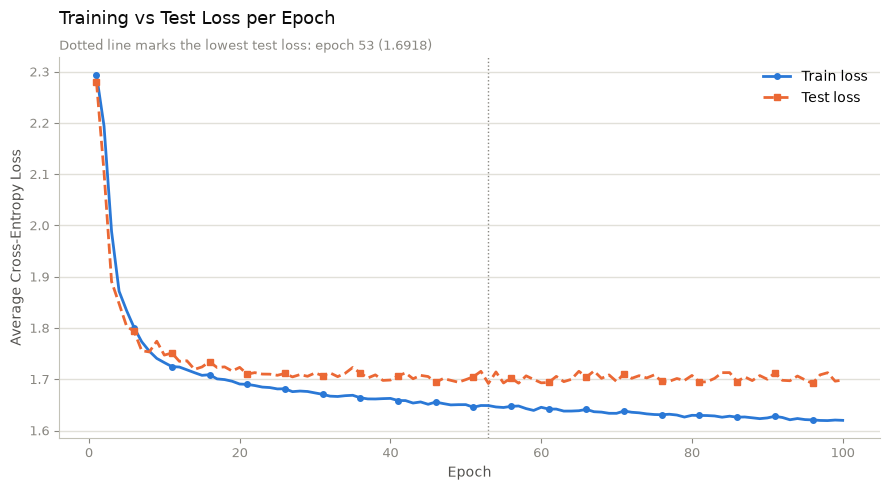

Final train loss: 1.6199
Final test loss : 1.6985
Generalization gap (test - train): 0.0786


In [27]:
# ===========================================================
# PLOT THE LEARNING CURVES (train loss vs test loss per epoch)
# ===========================================================
# `train_losses` and `test_losses` were filled in by the training loop above,
# one value per epoch. Plotting them together is the standard way to see whether
# the model is still learning, underfitting, or overfitting.
# ===========================================================

# Colours: colourblind-safe blue / orange pair. Line style + markers repeat the
# distinction, so the two series stay tellable apart in greyscale or print.
TRAIN_COLOR = '#2a78d6'   # blue
TEST_COLOR = '#eb6834'    # orange
MUTED = '#898781'         # axis / tick ink
GRID = '#e1e0d9'          # hairline gridlines
INK = '#52514e'           # label ink

epoch_axis = range(1, len(train_losses) + 1)     # x-axis: epoch 1..N
marker_gap = max(1, len(train_losses) // 20)     # Show ~20 markers, not one per epoch

fig, ax = plt.subplots(figsize=(9, 5))

# --- The two series ---
ax.plot(epoch_axis, train_losses,
        color=TRAIN_COLOR, linewidth=2, linestyle='-',
        marker='o', markersize=4, markevery=marker_gap,
        label='Train loss')

ax.plot(epoch_axis, test_losses,
        color=TEST_COLOR, linewidth=2, linestyle='--',
        marker='s', markersize=4, markevery=marker_gap,
        label='Test loss')

# --- Mark the epoch with the LOWEST test loss (the ideal early-stopping point) ---
# The dotted vertical line is the visual cue; the number goes in the subtitle below
# the title, so no floating text can collide with the curves.
best_epoch = test_losses.index(min(test_losses)) + 1
ax.axvline(best_epoch, color=MUTED, linewidth=1, linestyle=':', zorder=0)

# --- Title, subtitle and axis labels ---
ax.set_title('Training vs Test Loss per Epoch', fontsize=13, color='#0b0b0b', pad=24,
             loc='left')
ax.text(0, 1.02,
        f'Dotted line marks the lowest test loss: epoch {best_epoch} ({min(test_losses):.4f})',
        transform=ax.transAxes, fontsize=9, color=MUTED)
ax.set_xlabel('Epoch', fontsize=10, color=INK)
ax.set_ylabel('Average Cross-Entropy Loss', fontsize=10, color=INK)

# --- Recessive chrome: faint horizontal grid, no boxed-in frame ---
ax.grid(axis='y', color=GRID, linewidth=1)
ax.set_axisbelow(True)                      # Gridlines behind the data lines
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)      # Drop the top/right frame
for side in ('left', 'bottom'):
    ax.spines[side].set_color('#c3c2b7')
ax.tick_params(colors=MUTED, labelsize=9)

# --- Legend: identity is never carried by colour alone ---
ax.legend(frameon=False, fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

# Print the final numbers so the exact values are available, not just the picture
print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final test loss : {test_losses[-1]:.4f}")
print(f"Generalization gap (test - train): {test_losses[-1] - train_losses[-1]:.4f}")
